# CheckUp Agent — Verification Notebook

This notebook verifies each component of the LangGraph health agent end-to-end:

1. **Language Detection** — Telugu script, Romanized Telugu, English
2. **Translation** — Telugu ↔ English via Gemini
3. **Router** — Intent classification
4. **Graph Compilation** — LangGraph StateGraph structure
5. **Individual Nodes** — Health Q&A, Check-in, Escalation
6. **Full Agent Flow** — End-to-end message processing
7. **Scheduler Engine** — Medication reminders, trends, missed check-ins

## 0. Setup

Install dependencies and configure the environment.

In [1]:
import sys, os

# Add project src to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(project_root, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Load .env from project root
from dotenv import load_dotenv
load_dotenv(os.path.join(project_root, '.env'))

print(f'Project root: {project_root}')
print(f'Source path:  {src_path}')
print(f'GOOGLE_API_KEY set: {bool(os.environ.get("GOOGLE_API_KEY", ""))}')

Project root: /Users/tejapotu/School/Projects/agents/checkUp
Source path:  /Users/tejapotu/School/Projects/agents/checkUp/src
GOOGLE_API_KEY set: True


---
## 1. Language Detection (Offline — No API needed)

Verify that the detector correctly identifies Telugu script, Romanized Telugu, and English.

In [2]:
from checkup.language.detector import detect_language

test_cases = [
    # (input_text, expected_lang, description)
    ('నాకు తలనొప్పి గా ఉంది', 'te', 'Telugu script: I have a headache'),
    ('నాకు 2 రోజులుగా జ్వరం', 'te', 'Telugu script mixed with numbers'),
    ('naaku tala noppi ga undi', 'te', 'Romanized Telugu'),
    ('amma is not feeling well', 'te', 'Romanized Telugu hint: amma'),
    ('nanna ki BP ekkuva', 'te', 'Romanized Telugu hint: nanna'),
    ('I have a headache', 'en', 'Plain English'),
    ('What medicine should I take for diabetes?', 'en', 'English health question'),
    ('', 'en', 'Empty string'),
    ('   ', 'en', 'Whitespace only'),
    ('123 456', 'en', 'Numbers only'),
]

print(f'{"Input":<45} {"Expected":>8} {"Got":>8} {"Status":>8}')
print('─' * 75)

all_passed = True
for text, expected, desc in test_cases:
    result = detect_language(text)
    status = '✅' if result == expected else '❌'
    if result != expected:
        all_passed = False
    display_text = f'{desc} ({text[:20]}...)' if len(text) > 20 else f'{desc} ({text})'
    print(f'{display_text:<45} {expected:>8} {result:>8} {status:>8}')

print()
print('🎉 All language detection tests passed!' if all_passed else '⚠️ Some tests failed')

Input                                         Expected      Got   Status
───────────────────────────────────────────────────────────────────────────
Telugu script: I have a headache (నాకు తలనొప్పి గా ఉంద...)       te       te        ✅
Telugu script mixed with numbers (నాకు 2 రోజులుగా జ్వర...)       te       te        ✅
Romanized Telugu (naaku tala noppi ga ...)          te       te        ✅
Romanized Telugu hint: amma (amma is not feeling ...)       te       te        ✅
Romanized Telugu hint: nanna (nanna ki BP ekkuva)       te       te        ✅
Plain English (I have a headache)                   en       en        ✅
English health question (What medicine should...)       en       en        ✅
Empty string ()                                     en       en        ✅
Whitespace only (   )                               en       en        ✅
Numbers only (123 456)                              en       en        ✅

🎉 All language detection tests passed!


---
## 2. Telugu ↔ English Translation (Requires GOOGLE_API_KEY)

Verify that Gemini translates Telugu to English and back correctly.

In [3]:
from checkup.language.translator import translate_to_english, translate_response

# --- Telugu Script → English ---
telugu_input = 'నాకు తలనొప్పి గా ఉంది'
english_output = await translate_to_english(telugu_input)
print(f'Telugu Script → English')
print(f'  Input:  {telugu_input}')
print(f'  Output: {english_output}')
print()

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


Telugu Script → English
  Input:  నాకు తలనొప్పి గా ఉంది
  Output: I have a headache.



In [4]:
# --- Romanized Telugu → English ---
roman_input = 'naaku rendu rojuluga jalubu vaccindi, mandulu teesukunnanu'
english_output2 = await translate_to_english(roman_input)
print(f'Romanized Telugu → English')
print(f'  Input:  {roman_input}')
print(f'  Output: {english_output2}')
print()

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


Romanized Telugu → English
  Input:  naaku rendu rojuluga jalubu vaccindi, mandulu teesukunnanu
  Output: I've had a cold for two days, and I've been taking medicine.



In [5]:
# --- English → Telugu ---
english_input = 'You should drink plenty of water and rest. If fever persists for more than 3 days, please see a doctor.'
telugu_output = await translate_response(english_input, 'te')
print(f'English → Telugu')
print(f'  Input:  {english_input}')
print(f'  Output: {telugu_output}')
print()

# --- English passthrough (should return unchanged) ---
passthrough = await translate_response('Stay healthy!', 'en')
assert passthrough == 'Stay healthy!', 'English passthrough failed!'
print('✅ English passthrough works correctly')

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


English → Telugu
  Input:  You should drink plenty of water and rest. If fever persists for more than 3 days, please see a doctor.
  Output: నువ్వు బాగా నీళ్ళు తాగు, రెస్ట్ తీసుకో. జ్వరం మూడు రోజుల కన్నా ఎక్కువ ఉంటే, డాక్టరు దగ్గరికి వెళ్ళు నాయనా.

✅ English passthrough works correctly


---
## 3. Graph Compilation & Visualization

Verify the LangGraph compiles without errors and inspect its structure.

In [6]:
from checkup.agent.graph import build_graph, compile_graph

# Build (uncompiled) graph
graph = build_graph()
print('✅ Graph built successfully')
print(f'   Nodes: {list(graph.nodes.keys())}')
print()

# Compile
compiled = compile_graph()
print('✅ Graph compiled successfully')
print()

# Visualize as ASCII (shows the graph structure)
try:
    graph_repr = compiled.get_graph()
    print('Graph structure:')
    print(graph_repr.draw_ascii())
except Exception as e:
    print(f'Graph visualization not available: {e}')

✅ Graph built successfully
   Nodes: ['detect_language', 'route', 'health_qa', 'checkin', 'escalate', 'respond']

✅ Graph compiled successfully

Graph structure:
                    +-----------+                       
                    | __start__ |                       
                    +-----------+                       
                           *                            
                           *                            
                           *                            
                 +-----------------+                    
                 | detect_language |                    
                 +-----------------+                    
                           *                            
                           *                            
                           *                            
                      +-------+                         
                      | route |.                        
                  ....+-------+ ....    

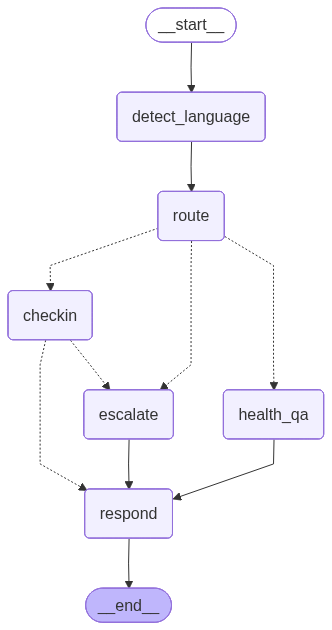

✅ Mermaid graph rendered


In [7]:
# Try to render as a Mermaid diagram (for nicer display)
try:
    from IPython.display import display, Image
    img_bytes = compiled.get_graph().draw_mermaid_png()
    display(Image(img_bytes))
    print('✅ Mermaid graph rendered')
except Exception as e:
    print(f'Mermaid rendering not available (install pyppeteer for PNG): {e}')
    # Fallback: print Mermaid text
    try:
        mermaid_text = compiled.get_graph().draw_mermaid()
        print('\nMermaid diagram (paste into mermaid.live):\n')
        print(mermaid_text)
    except Exception:
        pass

---
## 4. Router — Intent Classification

Test that the router correctly classifies different types of messages.

In [8]:
from checkup.agent.nodes.router import route

router_test_cases = [
    ('What should I eat if I have diabetes?', 'health_qa'),
    ('I am feeling fine today, had good sleep', 'checkin'),
    ('I have severe chest pain and can\'t breathe', 'escalate'),
    ('Did I take my morning medicine?', 'medication'),
    ('I want to register my health details', 'register'),
]

print(f'{"Message":<55} {"Expected":>12} {"Got":>12} {"Match":>6}')
print('─' * 90)

for text, expected_intent in router_test_cases:
    state = {'english_text': text, 'original_text': text}
    result = await route(state)
    got = result['intent']
    match = '✅' if got == expected_intent else '⚠️'
    print(f'{text:<55} {expected_intent:>12} {got:>12} {match:>6}')

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


Message                                                     Expected          Got  Match
──────────────────────────────────────────────────────────────────────────────────────────


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


What should I eat if I have diabetes?                      health_qa    health_qa      ✅


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


I am feeling fine today, had good sleep                      checkin      checkin      ✅


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


I have severe chest pain and can't breathe                  escalate     escalate      ✅


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


Did I take my morning medicine?                           medication   medication      ✅
I want to register my health details                        register     register      ✅


---
## 5. Individual Nodes

### 5a. Check-In Node — Processes daily health check-in responses

In [9]:
from checkup.agent.nodes.checkin import checkin

# --- Low-risk check-in ---
state_low = {'english_text': 'I am feeling good today. I ate well and went for a walk.'}
result_low = await checkin(state_low)

print('=== LOW RISK CHECK-IN ===')
print(f'Risk Level: {result_low["risk_level"]}')
print(f'Response:   {result_low["response_text"]}')
print(f'Alert:      {result_low.get("caregiver_alert", "None")}')
print()

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


=== LOW RISK CHECK-IN ===
Risk Level: low
Response:   That's wonderful to hear! It sounds like you had a really nice day. Keep up the great work!

```json
{
  "overall_feeling": "good",
  "appetite": "good",
  "activity_level": "walk",
  "pain_level": "none",
  "additional_notes": "Ate well and went for a walk, indicating a positive and active day."
}
```
Alert:      None



In [10]:
# --- High-risk check-in ---
state_high = {'english_text': 'I fell down in the bathroom and I have severe pain in my hip. I cannot stand up.'}
result_high = await checkin(state_high)

print('=== HIGH RISK CHECK-IN ===')
print(f'Risk Level: {result_high["risk_level"]}')
print(f'Response:   {result_high["response_text"]}')
print(f'Alert:      {result_high.get("caregiver_alert", "None")}')

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


=== HIGH RISK CHECK-IN ===
Risk Level: high
Response:   Oh no, I'm so sorry to hear that you fell and are in so much pain! It sounds like you need immediate help.

**Assessment:**

*   **Fall:** Yes, in the bathroom
*   **Pain Level:** Severe, in the hip
*   **Mobility:** Unable to stand

**Concerning symptoms:**

*   **Inability to stand**
*   **Severe pain**

I'm calling emergency services right away to get you the help you need. Please stay calm, and know that help is on the way.
Alert:      🚨 ALERT: Your parent reported concerning symptoms during today's check-in.

What they said: "I fell down in the bathroom and I have severe pain in my hip. I cannot stand up."

Please check on them as soon as possible.


### 5b. Escalation Node — Emergency handling

In [11]:
from checkup.agent.nodes.escalation import escalate

state_emergency = {
    'english_text': 'I have severe chest pain and difficulty breathing',
    'user_phone': '+911234567890',
    'caregiver_alert': None,
}
result_esc = await escalate(state_emergency)

print('=== ESCALATION ===')
print(f'Risk Level: {result_esc["risk_level"]}')
print(f'Response:\n{result_esc["response_text"]}')
print(f'\nCaregiver Alert:\n{result_esc["caregiver_alert"]}')

ESCALATION triggered for phone=+911234567890


=== ESCALATION ===
Risk Level: high
Response:
🚨 I understand this sounds serious. Here's what to do right now:

1. If you feel you're in danger, please call emergency services (108) immediately.
2. I'm alerting your family member right now so they can check on you.
3. Try to stay calm and sit or lie down in a comfortable position.
4. Don't take any new medication without talking to your doctor.

Your family has been notified. Someone will reach out to you very soon. 🙏

⚠️ This is not medical advice. Please call 108 or visit the nearest hospital for emergencies.


Caregiver Alert:
🚨 URGENT: Your parent has requested help or reported an emergency.

What they said: "I have severe chest pain and difficulty breathing"

Please contact them immediately or call emergency services (108).


---
## 6. Scheduler Engine (Offline — No API needed)

Verify medication reminder computation, weekly trend analysis, and missed check-in detection.

In [12]:
from checkup.scheduler.engine import (
    compute_medication_reminders,
    assess_weekly_trend,
    compute_missed_checkin_alert,
)
from datetime import datetime, timedelta

# --- Medication Reminders ---
medications = [
    {'name': 'Metformin', 'dosage': '500mg', 'times': ['08:00', '20:00']},
    {'name': 'Amlodipine', 'dosage': '5mg', 'times': ['09:00']},
    {'name': 'Atorvastatin', 'dosage': '10mg', 'times': ['21:00']},
]

reminders = compute_medication_reminders(medications)
print('=== MEDICATION REMINDERS (remaining today) ===')
for r in reminders:
    print(f'  💊 {r["medication_name"]} {r["dosage"]} at {r["scheduled_time"].strftime("%I:%M %p")}')
if not reminders:
    print('  (no remaining reminders today)')
print()

=== MEDICATION REMINDERS (remaining today) ===
  💊 Metformin 500mg at 08:00 PM
  💊 Atorvastatin 10mg at 09:00 PM



In [13]:
# --- Weekly Trend Analysis ---
print('=== WEEKLY TREND ANALYSIS ===')

scenarios = [
    ('Stable week', [{'risk_level': 'low'} for _ in range(7)]),
    ('Worsening',   [{'risk_level': 'high'}, {'risk_level': 'high'}, {'risk_level': 'low'}]),
    ('Needs attention', [{'risk_level': 'high'}] + [{'risk_level': 'low'}] * 6),
    ('Moderate',    [{'risk_level': 'medium'}] * 3 + [{'risk_level': 'low'}] * 4),
    ('No data',     []),
]

for name, logs in scenarios:
    trend = assess_weekly_trend(logs)
    emoji = {'stable': '🟢', 'worsening': '🔴', 'needs_attention': '🟡', 'moderate': '🟠', 'no_data': '⚪'}
    print(f'  {emoji.get(trend["trend"], "?")} {name:<20} → trend={trend["trend"]:<18} (H:{trend["high"]} M:{trend["medium"]} L:{trend["low"]})')
print()

=== WEEKLY TREND ANALYSIS ===
  🟢 Stable week          → trend=stable             (H:0 M:0 L:7)
  🔴 Worsening            → trend=worsening          (H:2 M:0 L:1)
  🟡 Needs attention      → trend=needs_attention    (H:1 M:0 L:6)
  🟠 Moderate             → trend=moderate           (H:0 M:3 L:4)
  ⚪ No data              → trend=no_data            (H:0 M:0 L:0)



In [14]:
# --- Missed Check-In Detection ---
print('=== MISSED CHECK-IN DETECTION ===')

# Scenario 1: No check-in today
yesterday = datetime.now() - timedelta(days=1)
missed = compute_missed_checkin_alert(last_checkin_time=yesterday, checkin_hour=0, threshold_hours=0)
print(f'  Last check-in yesterday, threshold passed → Alert: {missed}  {"✅" if missed else "❌"}')

# Scenario 2: Check-in received today
now = datetime.now()
not_missed = compute_missed_checkin_alert(last_checkin_time=now, checkin_hour=0, threshold_hours=0)
print(f'  Check-in today                           → Alert: {not_missed}  {"✅" if not not_missed else "❌"}')

# Scenario 3: Never checked in
never = compute_missed_checkin_alert(last_checkin_time=None, checkin_hour=0, threshold_hours=0)
print(f'  Never checked in, threshold passed        → Alert: {never}  {"✅" if never else "❌"}')

=== MISSED CHECK-IN DETECTION ===
  Last check-in yesterday, threshold passed → Alert: True  ✅
  Check-in today                           → Alert: False  ✅
  Never checked in, threshold passed        → Alert: True  ✅


---
## 7. Full Agent Flow — End-to-End

Run the complete LangGraph pipeline with different input messages.

> **Note:** This does NOT connect to WhatsApp. It simulates the same flow the webhook triggers.

In [15]:
from checkup.agent.graph import compile_graph
from langchain_core.messages import HumanMessage

agent = compile_graph()

async def run_agent(message: str, phone: str = '+911234567890'):
    """Run the full agent pipeline and display results."""
    initial_state = {
        'messages': [HumanMessage(content=message)],
        'user_phone': phone,
        'original_text': message,
        'detected_language': '',
        'english_text': '',
        'intent': '',
        'parent_profile_id': None,
        'rag_context': None,
        'health_summary': None,
        'risk_level': None,
        'response_text': '',
        'caregiver_alert': None,
    }

    result = await agent.ainvoke(
        initial_state,
        config={'configurable': {'thread_id': phone}},
    )

    print(f'📱 Input:     {message}')
    print(f'🌐 Language:  {result["detected_language"]}')
    print(f'🏷️  Intent:    {result["intent"]}')
    print(f'⚠️  Risk:      {result.get("risk_level", "n/a")}')
    print(f'💬 Response:  {result["response_text"][:300]}...' if len(result.get('response_text', '')) > 300 else f'💬 Response:  {result["response_text"]}')
    if result.get('caregiver_alert'):
        print(f'🚨 ALERT:     {result["caregiver_alert"]}')
    print()
    return result

In [16]:
# Test 1: Telugu health question
print('═' * 60)
print('TEST 1: Telugu health question')
print('═' * 60)
r1 = await run_agent('నాకు షుగర్ ఉంది, ఏమి తినాలి?')

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


════════════════════════════════════════════════════════════
TEST 1: Telugu health question
════════════════════════════════════════════════════════════


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
RAG retrieval failed: Collection elderly_health not found
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


📱 Input:     నాకు షుగర్ ఉంది, ఏమి తినాలి?
🌐 Language:  te
🏷️  Intent:    health_qa
⚠️  Risk:      None
💬 Response:  మీకు షుగర్ వ్యాధి ఉన్నప్పుడు ఏ ఆహారం మంచిదో తెలుసుకోవాలని అడుగుతున్నారని నాకు అర్థమైంది.

సాధారణంగా, కూరగాయలు, పండ్లు, మరియు ముడి ధాన్యాలు ఎక్కువగా ఉండే ఆహారం తీసుకోవడం మంచిది. మాంసం, చేపలు తినాలనుకుంటే కొవ్వు తక్కువగా ఉన్నవి ఎంచుకోండి. ఎంత తినాలి అనే దాని మీద కూడా శ్రద్ధ పెట్టాలి. రోజులో కొంచెం కొం...



In [17]:
# Test 2: English health question
print('═' * 60)
print('TEST 2: English health question')
print('═' * 60)
r2 = await run_agent('What should I eat to control my blood pressure?')

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


════════════════════════════════════════════════════════════
TEST 2: English health question
════════════════════════════════════════════════════════════


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
RAG retrieval failed: Collection elderly_health not found
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


📱 Input:     What should I eat to control my blood pressure?
🌐 Language:  en
🏷️  Intent:    health_qa
⚠️  Risk:      None
💬 Response:  I understand you're looking for foods that can help manage your blood pressure. That's a great step towards taking care of your health!

While I don't have specific dietary recommendations, a balanced diet that's low in salt and rich in fruits, vegetables, and whole grains is generally a good idea. ...



In [18]:
# Test 3: Romanized Telugu check-in
print('═' * 60)
print('TEST 3: Romanized Telugu check-in')
print('═' * 60)
r3 = await run_agent('baaga undi, nidra baaga vacchindi, mandulu teesukunnanu')

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


════════════════════════════════════════════════════════════
TEST 3: Romanized Telugu check-in
════════════════════════════════════════════════════════════


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


📱 Input:     baaga undi, nidra baaga vacchindi, mandulu teesukunnanu
🌐 Language:  te
🏷️  Intent:    checkin
⚠️  Risk:      low
💬 Response:  అబ్బో, అది వినడానికి చాలా సంతోషంగా ఉంది! ఈ రోజు మీరు బాగానే మొదలుపెట్టినట్టు ఉంది.

మీ ఆరోగ్యం గురించి కొంచెం సంగతులు:

**రోజు వారి ఆరోగ్యం:**

*   **మనసు:** బాగా ఉంది
*   **నిద్ర:** బాగా పట్టింది
*   **మందులు:** చెప్పినట్టుగానే వేసుకున్నారు

రోజంతా హాయిగా ఉండండి!



In [19]:
# Test 4: Emergency (should trigger escalation + caregiver alert)
print('═' * 60)
print('TEST 4: Emergency — should trigger caregiver alert')
print('═' * 60)
r4 = await run_agent('I have severe chest pain and I cannot breathe properly')

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


════════════════════════════════════════════════════════════
TEST 4: Emergency — should trigger caregiver alert
════════════════════════════════════════════════════════════


ESCALATION triggered for phone=+911234567890


📱 Input:     I have severe chest pain and I cannot breathe properly
🌐 Language:  en
🏷️  Intent:    escalate
⚠️  Risk:      high
💬 Response:  🚨 I understand this sounds serious. Here's what to do right now:

1. If you feel you're in danger, please call emergency services (108) immediately.
2. I'm alerting your family member right now so they can check on you.
3. Try to stay calm and sit or lie down in a comfortable position.
4. Don't take...
🚨 ALERT:     🚨 URGENT: Your parent has requested help or reported an emergency.

What they said: "I have severe chest pain and I cannot breathe properly"

Please contact them immediately or call emergency services (108).



In [20]:
# Test 5: Telugu emergency
print('═' * 60)
print('TEST 5: Telugu emergency')
print('═' * 60)
r5 = await run_agent('నాకు గుండెలో నొప్పి గా ఉంది, ఊపిరి రావడం లేదు')

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


════════════════════════════════════════════════════════════
TEST 5: Telugu emergency
════════════════════════════════════════════════════════════


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
ESCALATION triggered for phone=+911234567890
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


📱 Input:     నాకు గుండెలో నొప్పి గా ఉంది, ఊపిరి రావడం లేదు
🌐 Language:  te
🏷️  Intent:    escalate
⚠️  Risk:      high
💬 Response:  🚨 ఇది చాలా సీరియస్‌గా ఉందని నాకు అర్థమైంది. వెంటనే మీరు ఏమి చేయాలో చెబుతాను వినండి:

1. మీకు ప్రమాదంగా అనిపిస్తే, వెంటనే 108కి ఫోన్ చేయండి.
2. మీ బంధువులకు ఇప్పుడే కబురు పెడుతున్నాను, వాళ్ళు వచ్చి మిమ్మల్ని చూస్తారు.
3. ప్రశాంతంగా ఉండటానికి ప్రయత్నించండి. కుర్చీలో కూర్చోండి లేదా పడుకోండి.
4. డాక్టర్...
🚨 ALERT:     🚨 URGENT: Your parent has requested help or reported an emergency.

What they said: "I have chest pain and I'm having trouble breathing."

Please contact them immediately or call emergency services (108).



---
## 8. Prompt Templates

Preview the bilingual prompt templates.

In [21]:
from checkup.language.prompts import (
    get_checkin_prompt,
    get_medication_reminder,
    get_disclaimer,
)

print('=== Daily Check-In (Telugu) ===')
print(get_checkin_prompt('te'))
print()
print('=== Daily Check-In (English) ===')
print(get_checkin_prompt('en'))
print()
print('=== Medication Reminder (Telugu) ===')
print(get_medication_reminder('te', 'Metformin', '500mg'))
print()
print('=== Medication Reminder (English) ===')
print(get_medication_reminder('en', 'Metformin', '500mg'))
print()
print('=== Disclaimer (Telugu) ===')
print(get_disclaimer('te'))
print()
print('=== Disclaimer (English) ===')
print(get_disclaimer('en'))

=== Daily Check-In (Telugu) ===
🙏 నమస్కారం! ఈరోజు మీరు ఎలా ఉన్నారు?

మీకు ఏమైనా నొప్పులు, అలసట, లేదా ఏదైనా సమస్య ఉంటే చెప్పండి. మీ ఆరోగ్యం మాకు ముఖ్యం. ❤️

=== Daily Check-In (English) ===
🙏 Hello! How are you feeling today?

Please let me know if you have any pain, tiredness, or any issues. Your health matters to us. ❤️

=== Medication Reminder (Telugu) ===
💊 మందుల సమయం!

Metformin (500mg) తీసుకునే టైమ్ అయింది.
దయచేసి మీ మందు తీసుకోండి. తీసుకున్నాక 'తీసుకున్నాను' అని చెప్పండి. 🙏

=== Medication Reminder (English) ===
💊 Medication time!

It's time to take Metformin (500mg).
Please take your medicine and reply 'done' when you've taken it. 🙏

=== Disclaimer (Telugu) ===
⚠️ ఇది సాధారణ ఆరోగ్య సమాచారం మాత్రమే, వైద్య సలహా కాదు. దయచేసి మీ డాక్టర్‌ను సంప్రదించండి.

=== Disclaimer (English) ===
⚠️ This is general health information, not medical advice. Please consult your doctor for personalized guidance.


---
## ✅ Verification Summary

If all cells above ran successfully, the following components are verified:

| Component | Status |
|---|---|
| Language Detection | Telugu script, Romanized Telugu, English |
| Translation | Telugu ↔ English via Gemini |
| Graph Compilation | StateGraph builds and compiles |
| Router | Intent classification into 5 categories |
| Check-In Node | Risk assessment (low/medium/high) |
| Escalation Node | Emergency response + caregiver alert |
| Scheduler Engine | Med reminders, trends, missed check-ins |
| Full Agent Flow | End-to-end: Telugu/English → detect → route → respond |
| Prompt Templates | Bilingual check-ins, reminders, disclaimers |